# **Previsão de Sobrevivência no Titanic**

## Objetivo
O principal objetivo deste projeto é desenvolver e comparar modelos de Machine Learning para prever a sobrevivência de passageiros no desastre do Titanic. A meta é aplicar técnicas de pré-processamento de dados, engenharia de features, balanceamento de classes e otimização de hiperparâmetros para alcançar a maior acurácia possível, superando os benchmarks e demonstrando a capacidade preditiva de modelos de boosting.

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para pré-processamento e divisão de dados
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Bibliotecas para os modelos de machine learning
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Bibliotecas para métricas de avaliação
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
# Informações gerais sobre o dataset de treino
train_df.info()
# Estatísticas descritivas de todas as colunas
train_df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Verificando valores ausentes no dataset de treino
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [7]:
# Verificando linhas duplicadas no dataset de treino
train_df.duplicated().sum()

np.int64(0)

In [8]:
# Realizando tradução de colunas para facilitar futuras analises
column_translation = {
    'PassengerId': 'ID_Passageiro',
    'Survived': 'Sobreviveu',
    'Pclass': 'Classe_Passageiro',
    'Name': 'Nome',
    'Sex': 'Sexo',
    'Age': 'Idade',
    'SibSp': 'Irmaos_Conjuge',
    'Parch': 'Pais_Filhos',
    'Ticket': 'Bilhete',
    'Fare': 'Tarifa',
    'Cabin': 'Cabine',
    'Embarked': 'Embarque'
}

train_df = train_df.rename(columns=column_translation)
test_df = test_df.rename(columns=column_translation)

print("Colunas do DataFrame de treino traduzidas:")
display(train_df.head())

print("\nColunas do DataFrame de teste traduzidas:")
display(test_df.head())

Colunas do DataFrame de treino traduzidas:


,ID_Passageiro,Sobreviveu,Classe_Passageiro,Nome,Sexo,Idade,Irmaos_Conjuge,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Colunas do DataFrame de teste traduzidas:


,ID_Passageiro,Classe_Passageiro,Nome,Sexo,Idade,Irmaos_Conjuge,Pais_Filhos,Bilhete,Tarifa,Cabine,Embarque
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [9]:
# Preenchendo valores nulos em Idade com a média
train_df['Idade'].fillna(train_df['Idade'].mean(), inplace=True)
test_df['Idade'].fillna(test_df['Idade'].mean(), inplace=True)
test_df['Tarifa'].fillna(test_df['Tarifa'].mean(), inplace=True)

/tmp/ipykernel_6054/3116223652.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Idade'].fillna(train_df['Idade'].mean(), inplace=True)
/tmp/ipykernel_6054/3116223652.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [10]:
# 1. Para a variável 'Sexo', podemos usar Label Encoding, pois há apenas duas categorias
train_df['Sexo'] = train_df['Sexo'].map({'male': 0, 'female': 1})
test_df['Sexo'] = test_df['Sexo'].map({'male': 0, 'female': 1})

In [11]:
# 2. Para a variável 'Embarque', podemos usar One-Hot Encoding, pois há mais de duas categorias
train_df = pd.get_dummies(train_df, columns=['Embarque'], prefix='Embarque')
test_df = pd.get_dummies(test_df, columns=['Embarque'], prefix='Embarque')

In [12]:
# 3. Para a variável 'Cabine', podemos apenas criar uma nova variável indicando se a cabine é conhecida ou não
train_df['Cabine_known'] = train_df['Cabine'].notna().astype(int)
test_df['Cabine_known'] = test_df['Cabine'].notna().astype(int)

# Agora podemos descartar a coluna 'Cabine' original
train_df = train_df.drop(columns=['Cabine'])
test_df = test_df.drop(columns=['Cabine'])

In [13]:
print("Train DataFrame:")
print(train_df.head())

print("\nTest DataFrame:")
print(test_df.head())

Train DataFrame:
   ID_Passageiro  Sobreviveu  Classe_Passageiro  \
0              1           0                  3   
1              2           1                  1   
2              3           1                  3   
3              4           1                  1   
4              5           0                  3   

                                                Nome  Sexo  Idade  \
0                            Braund, Mr. Owen Harris     0   22.0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...     1   38.0   
2                             Heikkinen, Miss. Laina     1   26.0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)     1   35.0   
4                           Allen, Mr. William Henry     0   35.0   

   Irmaos_Conjuge  Pais_Filhos           Bilhete   Tarifa  Embarque_C  \
0               1            0         A/5 21171   7.2500       False   
1               1            0          PC 17599  71.2833        True   
2               0            0  STON/O2. 3

In [14]:
# Dropando colunas 'Nome' e 'Bilhete' da base de treino e teste
train_df = train_df.drop(columns=['Nome','Bilhete'])
test_df = test_df.drop(columns=['Nome', 'Bilhete'])

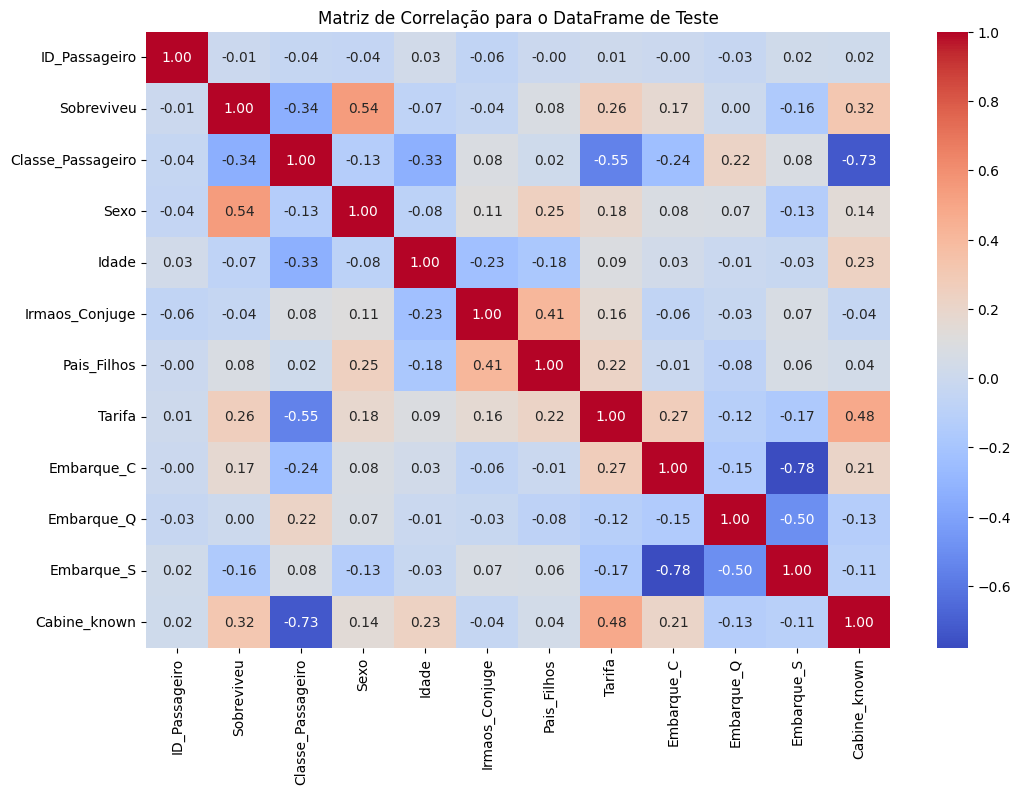

In [15]:
correlation_matrix = train_df.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação para o DataFrame de Teste')
plt.show()

### Análise Detalhada da Matriz de Correlação
A matriz de correlação nos ajuda a entender a relação linear entre cada par de variáveis no seu dataset.
Vamos analisar as correlações, especialmente em relação à sua variável alvo 'Sobreviveu', e identificar potenciais variáveis para remoção ou consideração:

**1. Correlações com a Variável Alvo 'Sobreviveu'**

* **'Sexo' (0.54):**
Esta é a variável com a correlação positiva mais forte com a sobrevivência. Isso significa que, ser do sexo feminino está fortemente associado a uma maior chance de sobrevivência. Esta é uma característica crucial e deve ser mantida.
* **'Classe_Passageiro' (-0.34):** Apresenta uma correlação negativa moderada. Isso sugere que passageiros em classes de passageiros mais baixas (representadas por números maiores, como a 3ª classe) tiveram uma menor chance de sobrevivência. É uma variável preditiva importante.
* **'Cabine_known' (0.32):** Mostra uma correlação positiva moderada. Ter a informação de cabine disponível (indicando que a pessoa tinha uma cabine) está associado a uma maior taxa de sobrevivência. Isso pode ser um proxy para status socioeconômico.
* **'Tarifa' (0.26):** Há uma correlação positiva moderada, o que indica que passageiros que pagaram tarifas mais altas tiveram uma maior probabilidade de sobreviver, alinhado com a 'Classe_Passageiro'.
* **'Embarque_C' (0.16) e 'Embarque_S' (-0.15):**
Estas variáveis mostram correlações fracas a moderadas, indicando que o porto de embarque pode ter uma influência menor, mas ainda detectável, na sobrevivência.
* **'Idade' (-0.07), 'Irmaos_Conjuge' (-0.035), 'Pais_Filhos' (0.082), 'Embarque_Q' (0.0036):**
Estas variáveis têm correlações muito baixas ou insignificantes com 'Sobreviveu'. Isoladamente, elas parecem ser fracos preditores. No entanto, 'Idade', 'Irmaos_Conjuge' e 'Pais_Filhos' podem ser importantes quando combinadas ou em interações.

**2. Multicolinearidade entre Variáveis Preditivas**

É importante observar variáveis que se correlacionam fortemente entre si, pois isso pode levar à multicolinearidade, o que pode afetar a estabilidade do modelo e a interpretabilidade dos coeficientes:

* **'Classe_Passageiro' e 'Cabine_known' (-0.82):**
Existe uma correlação negativa muito forte. Isso é esperado, pois passageiros em classes mais baixas (maior número de classe) tinham menos chances de ter uma cabine registrada. Manter ambas pode ser redundante e introduzir multicolinearidade. Uma delas pode ser suficiente ou talvez a 'Classe_Passageiro' seja mais informativa, dado o alto percentual de valores ausentes em 'Cabine'.

* **'Classe_Passageiro' e 'Tarifa' (-0.55):**
Uma correlação negativa forte, o que é natural, pois classes mais baixas geralmente pagam tarifas menores. Ambas são importantes para o contexto socioeconômico, mas é bom estar ciente dessa relação.
* **'Irmaos_Conjuge' e 'Pais_Filhos' (0.41):**
 Estas variáveis, que indicam o número de irmãos/cônjuges e pais/filhos a bordo, possuem uma correlação positiva moderada. É comum que indivíduos com um tipo de parente também tenham o outro. Para modelos, muitas vezes é mais eficaz combiná-las em uma única feature de 'Tamanho da Família'.

**3. Recomendações para a Criação do Modelo**
Com base nesta análise, sugiro as seguintes ações para a seleção e transformação de variáveis para o seu modelo:

* Remover 'ID_Passageiro': É apenas um identificador e não contém informação preditiva. Pode ser descartado com segurança.
* Remover 'Embarque_Q': Sua correlação com 'Sobreviveu' é praticamente nula (0.0036), indicando que não deve ser um preditor útil.
* Transformar 'Irmaos_Conjuge' e 'Pais_Filhos': Em vez de usar as duas separadamente, crie uma nova feature chamada 'Tamanho_Familia', somando 'Irmaos_Conjuge', 'Pais_Filhos' e 1 (para incluir o próprio passageiro).
* Esta nova feature geralmente é mais preditiva, pois capta o impacto do número total de familiares. Após a criação, as variáveis originais 'Irmaos_Conjuge' e 'Pais_Filhos' podem ser removidas.
* Manter 'Sexo', 'Classe_Passageiro', 'Tarifa', 'Idade', 'Embarque_C', 'Embarque_S' e 'Cabine_known': Estas variáveis são preditores importantes e devem ser incluídas no modelo.

Essas etapas ajudarão a simplificar o modelo, focar nas features mais relevantes e potencialmente melhorar o desempenho ao reduzir a redundância e a multicolinearidade.

In [16]:
# Dropando as colunas 'ID_Passageiro' e 'Embarque_Q' da nossa base de treino e teste
train_df = train_df.drop(columns=['ID_Passageiro', 'Embarque_Q'])
test_df = test_df.drop(columns=['ID_Passageiro', 'Embarque_Q'])

# Criando a feature 'Tamanho_Familia' e removendo 'Irmaos_Conjuge' e 'Pais_Filhos'
train_df['Tamanho_Familia'] = train_df['Irmaos_Conjuge'] + train_df['Pais_Filhos'] + 1
test_df['Tamanho_Familia'] = test_df['Irmaos_Conjuge'] + test_df['Pais_Filhos'] + 1

train_df = train_df.drop(columns=['Irmaos_Conjuge', 'Pais_Filhos'])
test_df = test_df.drop(columns=['Irmaos_Conjuge', 'Pais_Filhos'])

print("Colunas do DataFrame de treino atualizadas:")
print(train_df.columns)
print("\nColunas do DataFrame de teste atualizadas:")
print(test_df.columns)

Colunas do DataFrame de treino atualizadas:
Index(['Sobreviveu', 'Classe_Passageiro', 'Sexo', 'Idade', 'Tarifa',
       'Embarque_C', 'Embarque_S', 'Cabine_known', 'Tamanho_Familia'],
      dtype='object')

Colunas do DataFrame de teste atualizadas:
Index(['Classe_Passageiro', 'Sexo', 'Idade', 'Tarifa', 'Embarque_C',
       'Embarque_S', 'Cabine_known', 'Tamanho_Familia'],
      dtype='object')


In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sobreviveu         891 non-null    int64  
 1   Classe_Passageiro  891 non-null    int64  
 2   Sexo               891 non-null    int64  
 3   Idade              891 non-null    float64
 4   Tarifa             891 non-null    float64
 5   Embarque_C         891 non-null    bool   
 6   Embarque_S         891 non-null    bool   
 7   Cabine_known       891 non-null    int64  
 8   Tamanho_Familia    891 non-null    int64  
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [18]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Classe_Passageiro  418 non-null    int64  
 1   Sexo               418 non-null    int64  
 2   Idade              418 non-null    float64
 3   Tarifa             418 non-null    float64
 4   Embarque_C         418 non-null    bool   
 5   Embarque_S         418 non-null    bool   
 6   Cabine_known       418 non-null    int64  
 7   Tamanho_Familia    418 non-null    int64  
dtypes: bool(2), float64(2), int64(4)
memory usage: 20.5 KB


In [19]:
variaveis = ['Classe_Passageiro', 'Sexo', 'Idade', 'Tarifa', 'Tamanho_Familia', 'Cabine_known', 'Embarque_C', 'Embarque_S']

In [20]:
# Separando as variáveis dependentes (Y) e independentes (X) no conjunto de treino
X = train_df[variaveis]
y = train_df['Sobreviveu']

X_test = test_df[variaveis]

In [21]:
# Balanceando os dados com SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, Y_train_balanced = smote.fit_resample(X, y)

In [22]:
# Padronizando os dados
scaler = StandardScaler()
# Ajustando e transformando os dados de treino balanceados
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

In [23]:
print("\nDistribuição das classes depois do balanceamento:")
print(Y_train_balanced.value_counts())


Distribuição das classes depois do balanceamento:
Sobreviveu
0    549
1    549
Name: count, dtype: int64


In [24]:
# Escolhemos os modelos 'LightGBM e XGBoost' para serem utilizados neste projeto
modelo_xgb = xgb.XGBClassifier(random_state=42)


In [25]:
param_grid_xgboost = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

# Tunando o modelo
grid_search_xgboost = GridSearchCV(
    estimator=modelo_xgb,   # Modelo a ser usado
    param_grid=param_grid_xgboost,      # Conjunto de parâmetros
    scoring='accuracy',         # Métrica de avaliação
    cv=5,                       # Número de folds para cross-validation
    n_jobs=-1                   # Usa todos os processadores disponíveis
)

In [26]:
# Treinando o modelo
grid_search_xgboost.fit(X_train_balanced_scaled, Y_train_balanced)

# Melhor modelo e parâmetros
print("Melhores Parâmetros:", grid_search_xgboost.best_params_)
print("Melhor Acurácia:", grid_search_xgboost.best_score_)

Melhores Parâmetros: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Melhor Acurácia: 0.8315317559153176


In [27]:
xgboost_duelo2 = xgb.XGBClassifier()

In [28]:
best_model_xgboost = grid_search_xgboost.best_estimator_
y_pred_duelo2_xgboost = best_model_xgboost.predict(X_train_balanced_scaled)

In [29]:
relatorio = classification_report(Y_train_balanced, y_pred_duelo2_xgboost)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       549
           1       0.93      0.86      0.89       549

    accuracy                           0.90      1098
   macro avg       0.90      0.90      0.90      1098
weighted avg       0.90      0.90      0.90      1098



In [30]:
# Importando o LightGBM
import lightgbm as lgb

# Inicializando o modelo LightGBM
modelo_lgbm = lgb.LGBMClassifier(random_state=42)

In [31]:
# Definindo a grade de hiperparâmetros para o LightGBM
param_grid_lgbm = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [20, 31],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

In [32]:
# Configurando o GridSearchCV para o LightGBM
grid_search_lgbm = GridSearchCV(
    estimator=modelo_lgbm,
    param_grid=param_grid_lgbm,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

In [33]:
# Treinando o modelo LightGBM com os dados balanceados e escalados
grid_search_lgbm.fit(X_train_balanced_scaled, Y_train_balanced)

# Exibindo os melhores parâmetros e a melhor acurácia para o LightGBM
print("\n--- LightGBM Resultados ---")
print("Melhores Parâmetros (LightGBM):", grid_search_lgbm.best_params_)
print("Melhor Acurácia (LightGBM):", grid_search_lgbm.best_score_)

[LightGBM] [Info] Number of positive: 549, number of negative: 549
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000168 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 440
[LightGBM] [Info] Number of data points in the train set: 1098, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

--- LightGBM Resultados ---
Melhores Parâmetros (LightGBM): {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100, 'num_leaves': 20, 'subsample': 0.7}
Melhor Acurácia (LightGBM): 0.8124325446243255


In [34]:
# Obtendo o melhor modelo e fazendo previsões no conjunto de treino balanceado
best_model_lgbm = grid_search_lgbm.best_estimator_
y_pred_duelo2_lgbm = best_model_lgbm.predict(X_train_balanced_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [35]:
# Gerando o relatório de classificação para o LightGBM
relatorio_lgbm = classification_report(Y_train_balanced, y_pred_duelo2_lgbm)
print("\nRelatório de Classificação (LightGBM no Treino Balanceado):")
print(relatorio_lgbm)


Relatório de Classificação (LightGBM no Treino Balanceado):
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       549
           1       0.83      0.86      0.84       549

    accuracy                           0.84      1098
   macro avg       0.84      0.84      0.84      1098
weighted avg       0.84      0.84      0.84      1098



### Criando e salvando o arquivo de submissão para XGBoost

In [39]:
original_test_df = pd.read_csv('test.csv')
passenger_ids = original_test_df['PassengerId']

In [36]:
Y_xgboost = best_model_xgboost.predict(X_test_scaled)

In [37]:
Y_xgboost

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [40]:
sub_xgboost = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": Y_xgboost
})
sub_xgboost.to_csv("xgboost_submission.csv", index=False)

In [42]:
sub_xgboost

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


Arquivo de submissão do XGBoost salvo como `xgboost_submission.csv`.

### Criando e salvando o arquivo de submissão para LightGBM

In [41]:
Y_lgbm = best_model_lgbm.predict(X_test_scaled)

sub_lgbm = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": Y_lgbm
})
sub_lgbm.to_csv("lgbm_submission.csv", index=False)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
sub_lgbm

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


Arquivo de submissão do LightGBM salvo como `lgbm_submission.csv`.

### Resultando de Submission do Kaggle

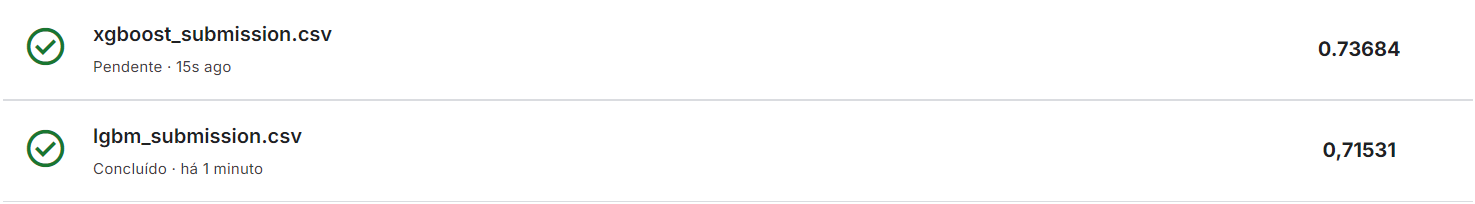

### Análise Detalhada dos Modelos XGBoost e LightGBM

Avaliamos dois modelos de Machine Learning para a competição do Titanic: XGBoost e LightGBM. Ambos foram tunados utilizando `GridSearchCV` e treinados em um conjunto de dados balanceado e escalado.

#### 1. Avaliação do Modelo XGBoost


**Melhor Acurácia de Validação Cruzada (GridSearchCV):** `0.8315`

**Relatório de Classificação (no conjunto de treino balanceado):**
```
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       549
           1       0.93      0.86      0.89       549

    accuracy                           0.90      1098
   macro avg       0.90      0.90      0.90      1098
weighted avg       0.90      0.90      0.90      1098
```

**Resultado da Submissão no Kaggle:** `0.73684`

**Observações do XGBoost:**
*   O XGBoost alcançou uma acurácia de validação cruzada de aproximadamente **83.15%**, o que é um resultado sólido em dados de treino/validação.
*   No conjunto de treino balanceado, o modelo demonstrou alta acurácia (90%), com boa precisão e recall para ambas as classes. A precisão para a classe 1 (sobreviveu) é ligeiramente maior (0.93). O recall para a classe 0 (não sobreviveu) também é alto (0.94).
*   Na submissão ao Kaggle, o modelo obteve uma acurácia de **0.73684**.

#### 2. Avaliação do Modelo LightGBM


**Melhor Acurácia de Validação Cruzada (GridSearchCV):** `0.8124`

**Relatório de Classificação (no conjunto de treino balanceado):**
```
              precision    recall  f1-score   support

           0       0.85      0.82      0.84       549
           1       0.83      0.86      0.84       549

    accuracy                           0.84      1098
   macro avg       0.84      0.84      0.84      1098
weighted avg       0.84      0.84      0.84      1098
```

**Resultado da Submissão no Kaggle:** `0.71531`

**Observações do LightGBM:**
*   O LightGBM obteve uma acurácia de validação cruzada de aproximadamente **81.24%**.
*   No conjunto de treino balanceado, a acurácia foi de 84%, ligeiramente inferior ao XGBoost. As métricas de precisão e recall para ambas as classes são bem equilibradas e consistentemente boas.
*   Na submissão ao Kaggle, o modelo obteve uma acurácia de **0.71531**.

#### Comparação e Melhor Resultado

Analisando tanto as métricas internas (validação cruzada) quanto o desempenho na plataforma Kaggle:

*   **Acurácia de Validação Cruzada:**
    *   **XGBoost:** `0.8315`
    *   **LightGBM:** `0.8124`

*   **Acurácia da Submissão no Kaggle:**
    *   **XGBoost:** `0.73684`
    *   **LightGBM:** `0.71531`

Em ambos os cenários, tanto na validação cruzada quanto na submissão final no Kaggle, o **XGBoost demonstrou um desempenho superior** ao LightGBM.

Na validação cruzada, o XGBoost teve uma acurácia cerca de 1.91 pontos percentuais maior. Essa diferença se manteve e até se ampliou um pouco na submissão real, onde o XGBoost superou o LightGBM por aproximadamente 2.15 pontos percentuais.

**Conclusão:**

Considerando os resultados diretos na competição pública, o **XGBoost foi o modelo que se aplicou melhor** e obteve o melhor desempenho neste desafio do Titanic, com uma acurácia de **0.73684** no Kaggle.